In [1]:
import numpy as np
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
import tensorflow_probability as tfp
from utils import CORR, UNCORR, CORR_FT, UNCORR_FT, plot_availability_heatmap
from gaussian_process_models.experiments import exp3
from gaussian_process_models.utils import get_cov_mat

In [2]:
from matplotlib import pyplot as plt

In [3]:
def _get_avail_mat(
    mean_seq,
    cov,
    seq_len,
    n_clients,
    freq1,
):

    y = np.random.multivariate_normal(mean=mean_seq, cov=cov, size=n_clients)
    thresh = np.quantile(y, [1 - freq1], method="higher", axis=1).T
    y_bin = (y >= thresh).astype(np.int8)

    return y_bin

2024-10-25 10:30:45.026158: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-10-25 10:30:45.029801: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-10-25 10:30:45.040404: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-10-25 10:30:45.057809: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-10-25 10:30:45.063024: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-10-25 10:30:45.075733: I tensorflow/core/platform/cpu_feature_gu

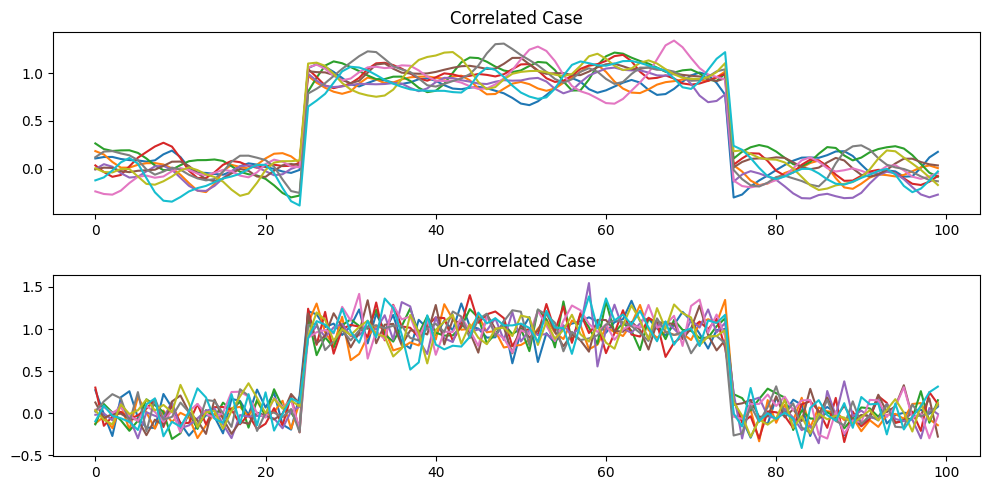

In [8]:
meafns = np.array([0 for _ in range(25)] + [1 for _ in range(50)] + [0 for _ in range(25)])
xlim = (-3, 3)
x = np.expand_dims(np.linspace(*xlim, 100), 1)
corr_cov = get_cov_mat(
        x=x,
        periodic_length_scale=1.0,
        period=1.0,
        amplitude=0.15,
        local_length_scale=1.0,
    )
uncorr_cov = get_cov_mat(
        x=x,
        periodic_length_scale=1.0,
        period=1.0,
        amplitude=0.15,
        local_length_scale=0.01,
    )

y_corr = np.random.multivariate_normal(mean=meafns, cov=corr_cov, size=10)
y_uncorr = np.random.multivariate_normal(mean=meafns, cov=uncorr_cov, size=10)

n_rows = 2
n_cols = 1

# Plot for y_corr
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 5))
axes = axes.ravel()
for _ in range(10):
    axes[0].plot(y_corr[_,:])
axes[0].set_title("Correlated Case")

for _ in range(10):
    axes[1].plot(y_uncorr[_,:])
axes[1].set_title("Un-correlated Case")

plt.tight_layout()
plt.show()

In [7]:
import pandas as pd

In [9]:
countries = [i+1 for i in range(7)]

In [38]:
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
from ipywidgets import interact, FloatSlider, VBox
import ipywidgets as widgets
import seaborn as sns

# Interactive function to plot correlated and uncorrelated cases
def plot_interactive(mean_amp, freq1, period, amplitude, local_length_scale_corr, local_length_scale_uncorr):
    meafns = np.array([0 for _ in range(12)] + [mean_amp for _ in range(25)] + [0 for _ in range(13)])
    xlim = (-3, 3)
    x = np.expand_dims(np.linspace(*xlim, 50), 1)

    # Generate correlated and uncorrelated covariance matrices
    corr_cov = get_cov_mat(
        x=x,
        periodic_length_scale=1.0,
        period=period,
        amplitude=amplitude,
        local_length_scale=local_length_scale_corr,
    )
    uncorr_cov = get_cov_mat(
        x=x,
        periodic_length_scale=1.0,
        period=period,
        amplitude=amplitude,
        local_length_scale=local_length_scale_uncorr,
    )

    # Generate samples from multivariate normal distribution
    y_corr = np.random.multivariate_normal(mean=meafns, cov=corr_cov, size=10)
    y_uncorr = np.random.multivariate_normal(mean=meafns, cov=uncorr_cov, size=10)
    
    
    avail_mat = {
        CORR: np.vstack(
            [
                _get_avail_mat(
                    mean_seq=meafns,
                    cov=corr_cov,
                    seq_len=50,
                    n_clients=1,
                    freq1=freq1,
                )
                for _ in range(7)
            ]
        ),
        UNCORR: np.vstack(
            [
                _get_avail_mat(
                    mean_seq=meafns,
                    cov=uncorr_cov,
                    seq_len=50,
                    n_clients=1,
                    freq1=freq1,
                )
                for _ in range(7)
            ]
        ),
        CORR_FT: np.hstack(
            (
                np.vstack(
                    [
                        _get_avail_mat(
                            mean_seq=meafns[:-3],
                            cov=corr_cov[:-3, :-3],
                            seq_len=50 - 3,
                            n_clients=1,
                            freq1=(freq1 * 50 - 3) / (50 - 3),
                        )
                        for _ in range(7)
                    ]
                ),
                np.ones((7, 3)),
            )
        ),
        UNCORR_FT: np.hstack(
            (
                np.vstack(
                    [
                        _get_avail_mat(
                            mean_seq=meafns[:-3],
                            cov=uncorr_cov[:-3, :-3],
                            seq_len=50 - 1-0,
                            n_clients=1,
                            freq1=(freq1 * 50 - 3) / (50 - 3),
                        )
                        for _ in range(7)
                    ]
                ),
                np.ones((7, 3)),
            )
        ),
    }

    n_rows = 4
    n_cols = 1

    # Plot correlated and uncorrelated cases
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 5))
    axes = axes.ravel()
    axes[0].cla()
    axes[1].cla()
    axes[2].cla()
    axes[3].cla()

    for _ in range(10):
        axes[0].plot(y_corr[_,:])
    axes[0].set_title("Correlated Case")
    
    formatted_array = list(range(50))
    
    availability_matrix = pd.DataFrame(avail_mat[CORR], index = countries, columns = formatted_array)
    
    
    cmap=LinearSegmentedColormap.from_list('rg',["r", "w", "g"], N=256) 
    sns.heatmap(availability_matrix.astype(int), annot=False, fmt='d', cbar=False, cmap=cmap, linewidths=0.5, linecolor='white', ax=axes[1]) # create heatmap

    if not isinstance(availability_matrix.columns[0], np.int64):
        plt.xticks(rotation=45, ha='right')  # rotate x-axis labels to diagonal
    xticks = axes[1].get_xticks()
    xticks = xticks[::2]
    axes[1].set_xticks(xticks) # set new xticks
    axes[1].set_title("Corr avail mat")

    for _ in range(10):
        axes[2].plot(y_uncorr[_,:])
    axes[2].set_title("Un-correlated Case")
    
    availability_matrix = pd.DataFrame(avail_mat[UNCORR], index = countries, columns = formatted_array)
    
    
    cmap=LinearSegmentedColormap.from_list('rg',["r", "w", "g"], N=256) 
    sns.heatmap(availability_matrix.astype(int), annot=False, fmt='d', cbar=False, cmap=cmap, linewidths=0.5, linecolor='white', ax=axes[3]) # create heatmap

    if not isinstance(availability_matrix.columns[0], np.int64):
        plt.xticks(rotation=45, ha='right')  # rotate x-axis labels to diagonal
    xticks = axes[1].get_xticks()
    xticks = xticks[::2]
    axes[3].set_xticks(xticks) # set new xticks
    axes[3].set_title("UnCorr avail mat")

    plt.tight_layout()
    plt.show()

# Sliders for interactive controls
mean_amp_slider = FloatSlider(min=0.0, max=1.0, step=0.1, value=0.5, Description="Mean max_val")
freq_slider = FloatSlider(min=0.2, max=1.0, step=0.05, value=0.4, Description="Freq")
period_slider = FloatSlider(min=0.1, max=1.0, step=0.1, value=0.8, description='Period')
amplitude_slider = FloatSlider(min=0.01, max=1.0, step=0.01, value=0.38, description='Amplitude')
local_length_scale_corr_slider = FloatSlider(min=0.01, max=2.0, step=0.01, value=1.0, description='Corr')
local_length_scale_uncorr_slider = FloatSlider(min=0.01, max=2.0, step=0.01, value=0.01, description='Uncorr')

# Interactive plot using ipywidgets
interact(
    plot_interactive,
    mean_amp = mean_amp_slider,
    freq1=freq_slider,
    period=period_slider,
    amplitude=amplitude_slider,
    local_length_scale_corr=local_length_scale_corr_slider,
    local_length_scale_uncorr=local_length_scale_uncorr_slider
)

interactive(children=(FloatSlider(value=0.5, description='mean_amp', max=1.0), FloatSlider(value=0.4, descript…

<function __main__.plot_interactive(mean_amp, freq1, period, amplitude, local_length_scale_corr, local_length_scale_uncorr)>

In [22]:
meafns = [
        np.array(
            [0 for _ in range(25)]
            + [1 for _ in range(50)]
            + [0 for _ in range(25)]
        )
        for _ in range(4)
    ] + [
        np.array([0 for _ in range(50)] + [1 for _ in range(50)])
        for _ in range(4)
    ]

In [24]:
meafns[0].shape

(100,)

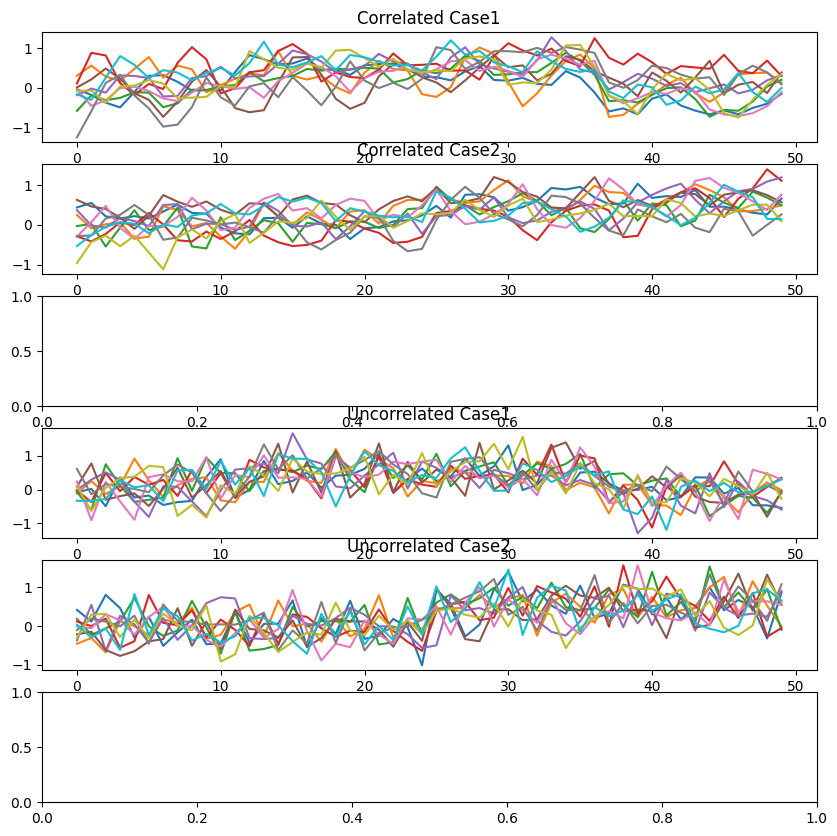

interactive(children=(FloatSlider(value=0.5, description='mean_amp', max=1.0), FloatSlider(value=0.4, descript…

<function __main__.plot_interactive(mean_amp, freq1, period, amplitude, local_length_scale_corr, local_length_scale_uncorr)>

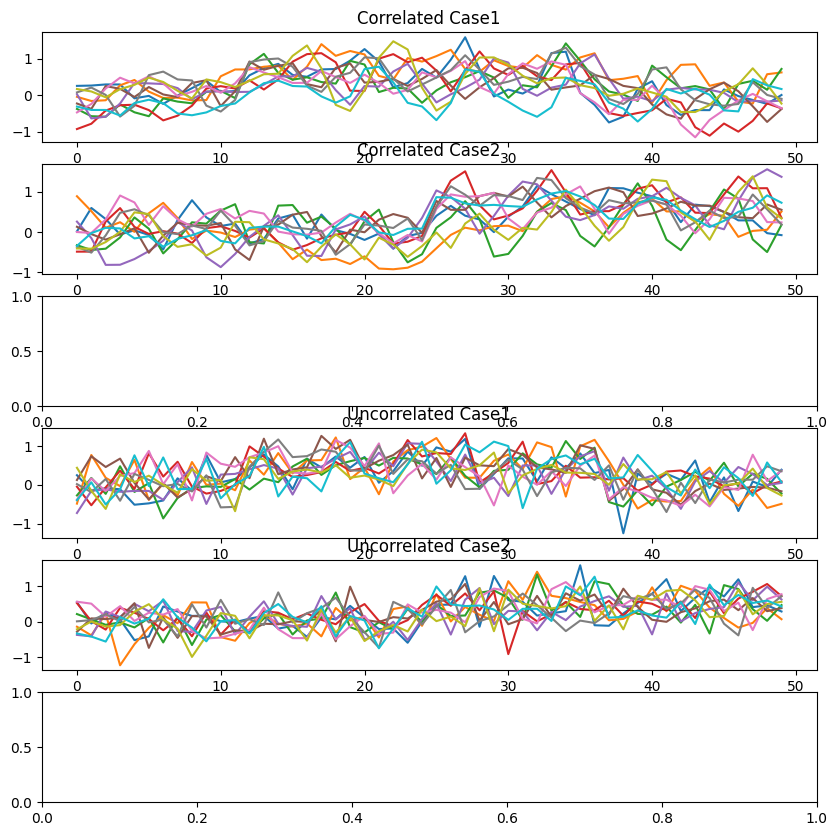

In [37]:
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
from ipywidgets import interact, FloatSlider, VBox
import ipywidgets as widgets
import seaborn as sns


# Interactive function to plot correlated and uncorrelated cases
def plot_interactive(
    mean_amp,
    freq1,
    period,
    amplitude,
    local_length_scale_corr,
    local_length_scale_uncorr,
):
    meafns = [
        np.array(
            [0 for _ in range(12)]
            + [mean_amp for _ in range(25)]
            + [0 for _ in range(13)]
        )
        for _ in range(4)
    ] + [
        np.array([0 for _ in range(25)] + [mean_amp for _ in range(25)])
        for _ in range(4)
    ]
    xlim = (-3, 3)
    x = np.expand_dims(np.linspace(*xlim, 50), 1)

    # Generate correlated and uncorrelated covariance matrices
    corr_cov = get_cov_mat(
        x=x,
        periodic_length_scale=1.0,
        period=period,
        amplitude=amplitude,
        local_length_scale=local_length_scale_corr,
    )
    uncorr_cov = get_cov_mat(
        x=x,
        periodic_length_scale=1.0,
        period=period,
        amplitude=amplitude,
        local_length_scale=local_length_scale_uncorr,
    )

    # Generate samples from multivariate normal distribution
    y_corr = np.random.multivariate_normal(mean=meafns[0], cov=corr_cov, size=10)
    y_uncorr = np.random.multivariate_normal(mean=meafns[0], cov=uncorr_cov, size=10)
    
    # Generate samples from multivariate normal distribution
    y_corr1 = np.random.multivariate_normal(mean=meafns[-1], cov=corr_cov, size=10)
    y_uncorr1 = np.random.multivariate_normal(mean=meafns[-1], cov=uncorr_cov, size=10)

    avail_mat = {
        CORR: np.vstack(
            [
                _get_avail_mat(
                    mean_seq=meafns[_],
                    cov=corr_cov,
                    seq_len=50,
                    n_clients=1,
                    freq1=freq1,
                )
                for _ in range(7)
            ]
        ),
        UNCORR: np.vstack(
            [
                _get_avail_mat(
                    mean_seq=meafns[_],
                    cov=uncorr_cov,
                    seq_len=50,
                    n_clients=1,
                    freq1=freq1,
                )
                for _ in range(7)
            ]
        ),
        CORR_FT: np.hstack(
            (
                np.vstack(
                    [
                        _get_avail_mat(
                            mean_seq=meafns[_][:-3],
                            cov=corr_cov[:-3, :-3],
                            seq_len=50 - 3,
                            n_clients=1,
                            freq1=(freq1 * 50 - 3) / (50 - 3),
                        )
                        for _ in range(7)
                    ]
                ),
                np.ones((7, 3)),
            )
        ),
        UNCORR_FT: np.hstack(
            (
                np.vstack(
                    [
                        _get_avail_mat(
                            mean_seq=meafns[_][:-3],
                            cov=uncorr_cov[:-3, :-3],
                            seq_len=50 - 1 - 0,
                            n_clients=1,
                            freq1=(freq1 * 50 - 3) / (50 - 3),
                        )
                        for _ in range(7)
                    ]
                ),
                np.ones((7, 3)),
            )
        ),
    }

    n_rows = 6
    n_cols = 1

    # Plot correlated and uncorrelated cases
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 10))
    axes = axes.ravel()
    axes[0].cla()
    axes[1].cla()
    axes[2].cla()
    axes[3].cla()
    axes[4].cla()
    axes[5].cla()

    for _ in range(10):
        axes[0].plot(y_corr[_, :])
        axes[1].plot(y_corr1[_, :])
        axes[3].plot(y_uncorr[_, :])
        axes[4].plot(y_uncorr1[_, :])
        
    axes[0].set_title("Correlated Case1")
    axes[1].set_title("Correlated Case2")
    axes[3].set_title("Uncorrelated Case1")
    axes[4].set_title("Uncorrelated Case2")

    formatted_array = list(range(100))

    availability_matrix = pd.DataFrame(
        avail_mat[CORR], index=countries, columns=formatted_array
    )

    cmap = LinearSegmentedColormap.from_list("rg", ["r", "w", "g"], N=256)
    sns.heatmap(
        availability_matrix.astype(int),
        annot=False,
        fmt="d",
        cbar=False,
        cmap=cmap,
        linewidths=0.5,
        linecolor="white",
        ax=axes[2],
    )  # create heatmap

    if not isinstance(availability_matrix.columns[0], np.int64):
        plt.xticks(rotation=45, ha="right")  # rotate x-axis labels to diagonal
    xticks = axes[2].get_xticks()
    xticks = xticks[::2]
    axes[2].set_xticks(xticks)  # set new xticks
    axes[2].set_title("Corr avail mat")

    availability_matrix = pd.DataFrame(
        avail_mat[UNCORR], index=countries, columns=formatted_array
    )

    cmap = LinearSegmentedColormap.from_list("rg", ["r", "w", "g"], N=256)
    sns.heatmap(
        availability_matrix.astype(int),
        annot=False,
        fmt="d",
        cbar=False,
        cmap=cmap,
        linewidths=0.5,
        linecolor="white",
        ax=axes[5],
    )  # create heatmap

    if not isinstance(availability_matrix.columns[0], np.int64):
        plt.xticks(rotation=45, ha="right")  # rotate x-axis labels to diagonal
    xticks = axes[5].get_xticks()
    xticks = xticks[::2]
    axes[5].set_xticks(xticks)  # set new xticks
    axes[5].set_title("UnCorr avail mat")

    plt.tight_layout()
    plt.show()


# Sliders for interactive controls
mean_amp_slider = FloatSlider(
    min=0.0, max=1.0, step=0.1, value=0.5, Description="Mean max_val"
)
freq_slider = FloatSlider(min=0.2, max=1.0, step=0.05, value=0.4, Description="Freq")
period_slider = FloatSlider(min=0.1, max=1.0, step=0.1, value=0.8, description="Period")
amplitude_slider = FloatSlider(
    min=0.01, max=1.0, step=0.01, value=0.38, description="Amplitude"
)
local_length_scale_corr_slider = FloatSlider(
    min=0.01, max=2.0, step=0.01, value=1.0, description="Corr"
)
local_length_scale_uncorr_slider = FloatSlider(
    min=0.01, max=2.0, step=0.01, value=0.01, description="Uncorr"
)

# Interactive plot using ipywidgets
interact(
    plot_interactive,
    mean_amp=mean_amp_slider,
    freq1=freq_slider,
    period=period_slider,
    amplitude=amplitude_slider,
    local_length_scale_corr=local_length_scale_corr_slider,
    local_length_scale_uncorr=local_length_scale_uncorr_slider,
)

# Create Mat for spatial correlation 1

In [11]:
meafns = {f'C{i}':np.array([0 for _ in range(25)] + [0.5 for _ in range(50)] + [0 for _ in range(25)]) for i in range(7)}
res = exp3(freq1=0.25, mean_seq=meafns,periodic_length_scale=1.0, period=0.8, amplitude=0.38, k=10, seq_len=100, n_clients=7)
formatted_array = list(range(100))

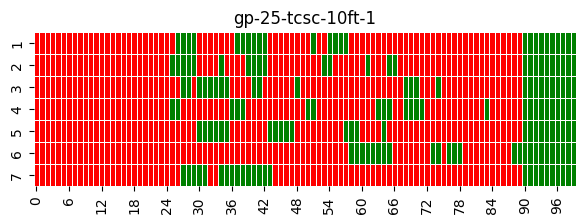

In [19]:
tmp = res[CORR_FT]
folder = 'availability_matrices/av-mat-4'
key_word = 'gp-25-tcsc-10ft-1'

availability_matrix = pd.DataFrame(tmp, index = countries, columns = formatted_array)

plot_availability_heatmap("", availability_matrix, key_word, folder=folder)
availability_matrix.to_csv(folder+'/av-mat_'+key_word+'.csv', columns=formatted_array)

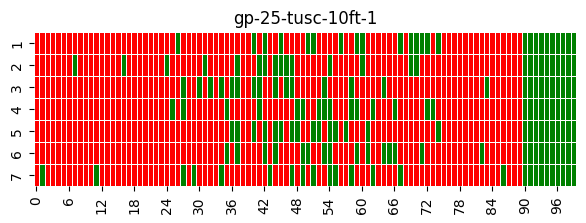

In [20]:
tmp = res[UNCORR_FT]
folder = 'availability_matrices/av-mat-4'
key_word = 'gp-25-tusc-10ft-1'

availability_matrix = pd.DataFrame(tmp, index = countries, columns = formatted_array)

plot_availability_heatmap("", availability_matrix, key_word, folder=folder)
availability_matrix.to_csv(folder+'/av-mat_'+key_word+'.csv', columns=formatted_array)

In [31]:
res = exp3(freq1=0.35, mean_seq=meafns,periodic_length_scale=1.0, period=0.8, amplitude=0.38, k=10, seq_len=100, n_clients=7)

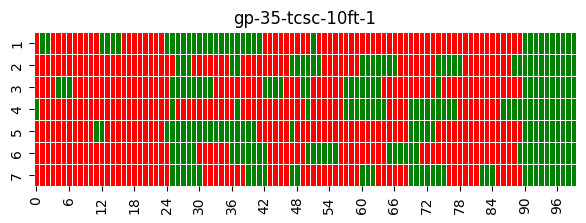

In [32]:
tmp = res[CORR_FT]
folder = 'availability_matrices/av-mat-4'
key_word = 'gp-35-tcsc-10ft-1'

availability_matrix = pd.DataFrame(tmp, index = countries, columns = formatted_array)

plot_availability_heatmap("", availability_matrix, key_word, folder=folder)
availability_matrix.to_csv(folder+'/av-mat_'+key_word+'.csv', columns=formatted_array)

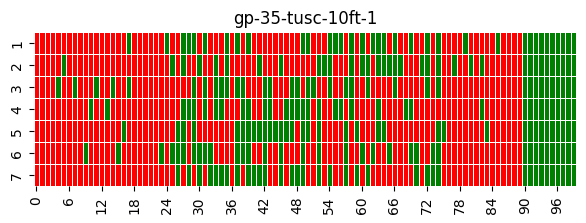

In [33]:
tmp = res[UNCORR_FT]
folder = 'availability_matrices/av-mat-4'
key_word = 'gp-35-tusc-10ft-1'

availability_matrix = pd.DataFrame(tmp, index = countries, columns = formatted_array)

plot_availability_heatmap("", availability_matrix, key_word, folder=folder)
availability_matrix.to_csv(folder+'/av-mat_'+key_word+'.csv', columns=formatted_array)

In [34]:
res = exp3(freq1=0.5, mean_seq=meafns,periodic_length_scale=1.0, period=0.8, amplitude=0.38, k=10, seq_len=100, n_clients=7)

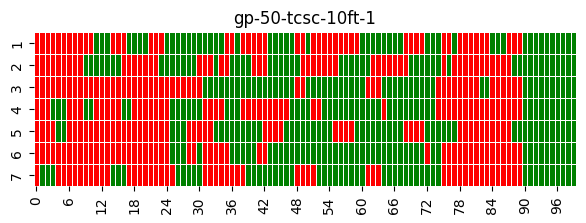

In [35]:
tmp = res[CORR_FT]
folder = 'availability_matrices/av-mat-4'
key_word = 'gp-50-tcsc-10ft-1'

availability_matrix = pd.DataFrame(tmp, index = countries, columns = formatted_array)

plot_availability_heatmap("", availability_matrix, key_word, folder=folder)
availability_matrix.to_csv(folder+'/av-mat_'+key_word+'.csv', columns=formatted_array)

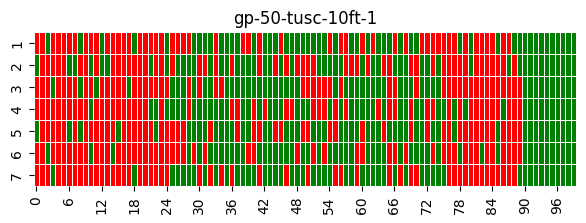

In [36]:
tmp = res[UNCORR_FT]
folder = 'availability_matrices/av-mat-4'
key_word = 'gp-50-tusc-10ft-1'

availability_matrix = pd.DataFrame(tmp, index = countries, columns = formatted_array)

plot_availability_heatmap("", availability_matrix, key_word, folder=folder)
availability_matrix.to_csv(folder+'/av-mat_'+key_word+'.csv', columns=formatted_array)

# Create Mat for spatial correlation 2

In [12]:
formatted_array = list(range(50))

In [ ]:
meafns = {'C0':np.array([0 for _ in range(12)] + [0.5 for _ in range(25)] + [0 for _ in range(13)]),
          'C1':np.array([0 for _ in range(12)] + [0.5 for _ in range(25)] + [0 for _ in range(13)]),
          'C2':np.array([0 for _ in range(12)] + [0.5 for _ in range(25)] + [0 for _ in range(13)]),
          'C3':np.array([0 for _ in range(12)] + [0.5 for _ in range(25)] + [0 for _ in range(13)]),
          'C4':np.array([0 for _ in range(25)] + [0.5 for _ in range(25)]),
          'C5':np.array([0 for _ in range(25)] + [0.5 for _ in range(25)]),
          'C6':np.array([0 for _ in range(25)] + [0.5 for _ in range(25)])
          }
res = exp3(freq1=0.25, mean_seq=meafns,periodic_length_scale=1.0, period=0.6, amplitude=0.38, k=3, seq_len=50, n_clients=7)

2025-04-15 15:03:47.389384: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744709627.406732  185505 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744709627.411347  185505 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1744709627.426090  185505 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1744709627.426111  185505 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1744709627.426113  185505 computation_placer.cc:177] computation placer alr

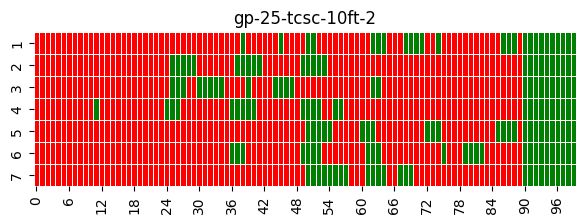

In [ ]:
tmp = res[CORR_FT]
folder = 'availability_matrices/av-mat-6'
key_word = 'gp-25-tcsc-3ft'

availability_matrix = pd.DataFrame(tmp, index = countries, columns = formatted_array)

plot_availability_heatmap("", availability_matrix, key_word, folder=folder)
availability_matrix.to_csv(folder+'/av-mat_'+key_word+'.csv', columns=formatted_array)

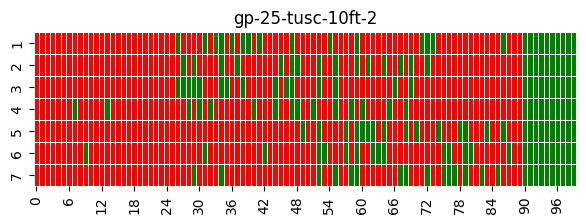

In [ ]:
tmp = res[UNCORR_FT]
folder = 'availability_matrices/av-mat-6'
key_word = 'gp-25-tusc-3ft'

availability_matrix = pd.DataFrame(tmp, index = countries, columns = formatted_array)

plot_availability_heatmap("", availability_matrix, key_word, folder=folder)
availability_matrix.to_csv(folder+'/av-mat_'+key_word+'.csv', columns=formatted_array)

In [48]:
res = exp3(freq1=0.35, mean_seq=meafns,periodic_length_scale=0.8, period=0.8, amplitude=0.32, k=3, seq_len=50, n_clients=7)

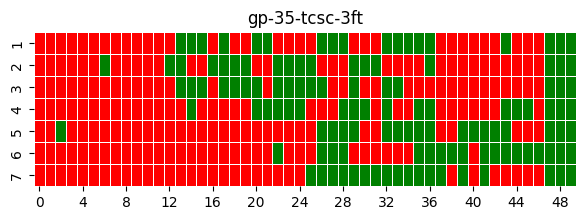

In [49]:
tmp = res[CORR_FT]
folder = 'availability_matrices/av-mat-6'
key_word = 'gp-35-tcsc-3ft'

availability_matrix = pd.DataFrame(tmp, index = countries, columns = formatted_array)

plot_availability_heatmap("", availability_matrix, key_word, folder=folder)
availability_matrix.to_csv(folder+'/av-mat_'+key_word+'.csv', columns=formatted_array)

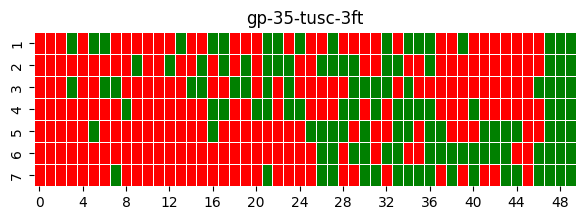

In [50]:
tmp = res[UNCORR_FT]
folder = 'availability_matrices/av-mat-6'
key_word = 'gp-35-tusc-3ft'

availability_matrix = pd.DataFrame(tmp, index = countries, columns = formatted_array)

plot_availability_heatmap("", availability_matrix, key_word, folder=folder)
availability_matrix.to_csv(folder+'/av-mat_'+key_word+'.csv', columns=formatted_array)

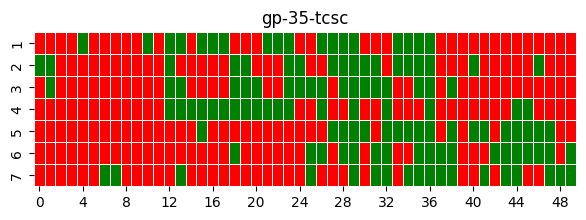

In [51]:
tmp = res[CORR]
folder = 'availability_matrices/av-mat-6'
key_word = 'gp-35-tcsc'

availability_matrix = pd.DataFrame(tmp, index = countries, columns = formatted_array)

plot_availability_heatmap("", availability_matrix, key_word, folder=folder)
availability_matrix.to_csv(folder+'/av-mat_'+key_word+'.csv', columns=formatted_array)

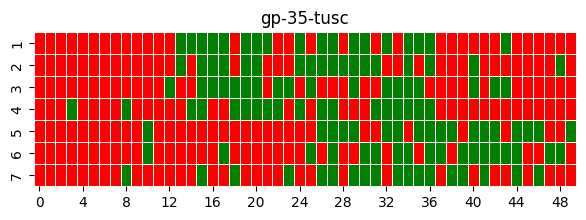

In [52]:
tmp = res[UNCORR]
folder = 'availability_matrices/av-mat-6'
key_word = 'gp-35-tusc'

availability_matrix = pd.DataFrame(tmp, index = countries, columns = formatted_array)

plot_availability_heatmap("", availability_matrix, key_word, folder=folder)
availability_matrix.to_csv(folder+'/av-mat_'+key_word+'.csv', columns=formatted_array)

In [53]:
res = exp3(freq1=0.5, mean_seq=meafns,periodic_length_scale=0.8, period=0.8, amplitude=0.32, k=3, seq_len=50, n_clients=7)

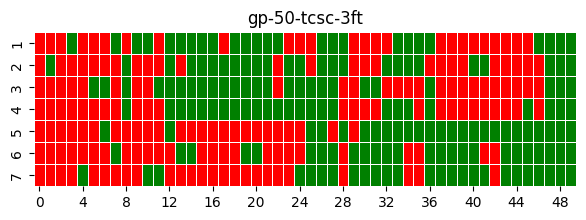

In [54]:
tmp = res[CORR_FT]
folder = 'availability_matrices/av-mat-6'
key_word = 'gp-50-tcsc-3ft'

availability_matrix = pd.DataFrame(tmp, index = countries, columns = formatted_array)

plot_availability_heatmap("", availability_matrix, key_word, folder=folder)
availability_matrix.to_csv(folder+'/av-mat_'+key_word+'.csv', columns=formatted_array)

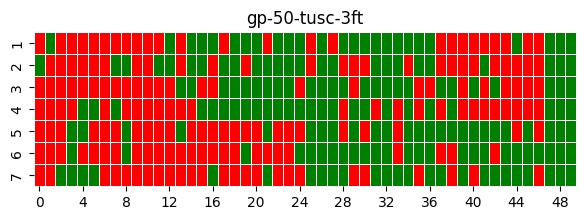

In [55]:
tmp = res[UNCORR_FT]
folder = 'availability_matrices/av-mat-6'
key_word = 'gp-50-tusc-3ft'

availability_matrix = pd.DataFrame(tmp, index = countries, columns = formatted_array)

plot_availability_heatmap("", availability_matrix, key_word, folder=folder)
availability_matrix.to_csv(folder+'/av-mat_'+key_word+'.csv', columns=formatted_array)

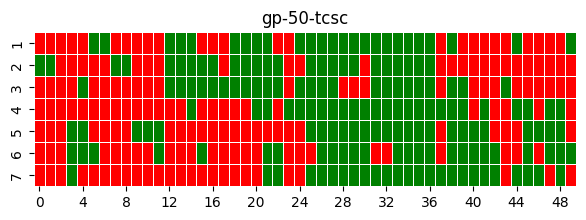

In [56]:
tmp = res[CORR]
folder = 'availability_matrices/av-mat-6'
key_word = 'gp-50-tcsc'

availability_matrix = pd.DataFrame(tmp, index = countries, columns = formatted_array)

plot_availability_heatmap("", availability_matrix, key_word, folder=folder)
availability_matrix.to_csv(folder+'/av-mat_'+key_word+'.csv', columns=formatted_array)

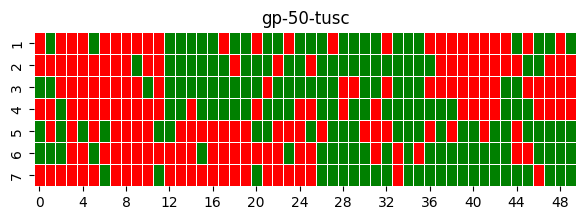

In [57]:
tmp = res[UNCORR]
folder = 'availability_matrices/av-mat-6'
key_word = 'gp-50-tusc'

availability_matrix = pd.DataFrame(tmp, index = countries, columns = formatted_array)

plot_availability_heatmap("", availability_matrix, key_word, folder=folder)
availability_matrix.to_csv(folder+'/av-mat_'+key_word+'.csv', columns=formatted_array)